# Feature selection

Runs locally against the `.venv`, reading Postgres on `localhost:5433`.

Everything here imports from `src/`, so whatever you settle on is the same
code the container runs via `docker compose run --rm train` -- there is no
second copy to keep in sync.

In [1]:
# Makes `import src...` work from inside notebooks/ by putting the repo root
# on the path. Only needed in the notebook: the container sets PYTHONPATH=/app.
import sys
from pathlib import Path

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

%load_ext autoreload
%autoreload 2

In [2]:
from src.data.db_link import check_connection, get_engine, load_dataframe

# Fails here rather than three cells later if .env is wrong or the database
# is not running.
check_connection()

True

## Find your table

`config/ml_config.yaml` ships with a placeholder query. Run the cell below to
see what is actually in the database, then put the real table name in the
config.

In [3]:
import pandas as pd

# Excludes Postgres' own internal catalogs, which are not your data.
load_dataframe("""
    SELECT table_schema, table_name
    FROM information_schema.tables
    WHERE table_schema NOT IN ('pg_catalog', 'information_schema')
    ORDER BY table_schema, table_name
""")

,table_schema,table_name
0,public,cleaned_transactions
1,public,feature_store_monthly
2,public,feature_store_monthly_scale
3,public,raw_transactions
4,public,rule_mcc_categories
5,public,rule_processing_codes
6,public,rule_spending_categories
7,public,staging_cleaned_transactions
8,public,staging_feature_store_monthly
9,public,staging_feature_store_monthly_scale


In [4]:
# Once you know the table, point the config at it and load through the same
# code path the container uses.
from src.config.config import load_config

config = load_config()
df = load_dataframe(config["data"]["query"])
print(df.shape)
df.head()

(6450, 28)


,user_id,month,prev_1m_closing_balance_usd,prev_2m_closing_balance_usd,prev_3m_closing_balance_usd,roll3_mean_closing_balance_usd,roll3_std_closing_balance_usd,delta_prev_1m_2m_closing_balance_usd,prev_1m_total_credited_usd,prev_1m_total_debited_usd,...,days_in_month,prev_1m_total_spend_usd,prev_1m_spend_groceries_usd,prev_1m_spend_dining_usd,prev_1m_spend_retail_usd,prev_1m_spend_cash_atm_usd,prev_1m_spend_transport_usd,prev_1m_spend_bills_usd,prev_1m_spend_other_usd,target_closing_balance_usd
0,05167b37-6076-5289-be16-0e4b4fc94ebe,2022-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-7977.17
1,05167b37-6076-5289-be16-0e4b4fc94ebe,2022-02-01,-7977.17,NaN,NaN,NaN,NaN,NaN,11144.99,20591.98,...,28,9843.35,284.36,190.28,5353.25,417.55,564.16,2734.67,299.08,-8911.64
2,05167b37-6076-5289-be16-0e4b4fc94ebe,2022-03-01,-8911.64,-7977.17,NaN,NaN,NaN,-934.47,3203.10,4169.82,...,31,2969.39,232.32,110.98,518.35,222.02,874.39,415.76,595.57,-10858.14
3,05167b37-6076-5289-be16-0e4b4fc94ebe,2022-04-01,-10858.14,-8911.64,-7977.17,-9248.9833,1469.8120,-1946.50,2243.11,4195.27,...,30,3994.30,333.50,315.57,515.64,125.82,694.89,1451.70,557.18,-12654.00
4,05167b37-6076-5289-be16-0e4b4fc94ebe,2022-05-01,-12654.00,-10858.14,-8911.64,-10807.9267,1871.6852,-1795.86,2158.58,3986.79,...,31,3785.48,754.34,210.68,433.83,105.15,946.62,815.82,519.04,-15359.36


## Exploratory data checks

Ten checks, in order: target distribution, target over time, missing values,
feature distributions, near-constant features, correlations, highly correlated
pairs, user differences, outliers, months per user.

Set `USER_COLUMN` and `TIME_COLUMN` by hand below if the automatic name
detection picks the wrong columns.

Plot conventions used throughout: no grid or reference lines, and every bar
carries its own value -- above the bar where it fits, inside the end in white
where the bar is too long for that.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FixedLocator, FuncFormatter, MaxNLocator, NullLocator

# --- house style ---------------------------------------------------------
# style="white" rather than "whitegrid": the grid was competing with the bars
# for attention, and on the heavy-tailed columns below it added lines without
# adding information.
sns.set_theme(style="white", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": False,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "figure.titlesize": 15,
    "figure.titleweight": "bold",
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "legend.frameon": False,
})

BLUE, ORANGE, RED, GREY = "#4C72B0", "#DD8452", "#C44E52", "#8C8C8C"


# --- plot helpers --------------------------------------------------------
# This is money data: most columns run from large negatives to very large
# positives with a median near zero, so a plain linear axis puts 99% of the
# rows into one bar. These helpers exist to keep those columns readable.

def compact(value, _position=None):
    """231000000 -> '231M', -15376 -> '-15.4k', 0.42 -> '0.42'.

    Matplotlib's default is a shared `1e8` offset parked in the corner of the
    axis, which turns every tick into a two-step calculation.
    """
    if value is None or (isinstance(value, float) and not np.isfinite(value)):
        return ""
    magnitude = abs(value)
    for size, suffix in ((1e9, "B"), (1e6, "M"), (1e3, "k")):
        if magnitude >= size:
            scaled = value / size
            text = f"{scaled:.1f}" if abs(scaled) < 100 else f"{scaled:.0f}"
            # Trim a trailing ".0" and nothing else. A blanket rstrip("0")
            # turns "100" into "1", which silently mislabels every 100k tick
            # on the axis as 1k.
            if text.endswith(".0"):
                text = text[:-2]
            return text + suffix
    if magnitude == 0:
        return "0"
    if magnitude >= 1:
        # Keep one decimal when the tick is not a whole number, or an axis
        # ticked every 0.5 prints "2" twice in a row.
        return f"{value:,.0f}" if float(value).is_integer() else f"{value:,.1f}"
    return f"{value:.2g}"


def money_axis(ax, axis="x"):
    """Put `compact` labels on one or both axes of `ax`."""
    formatter = FuncFormatter(compact)
    if axis in ("x", "both"):
        ax.xaxis.set_major_formatter(formatter)
    if axis in ("y", "both"):
        ax.yaxis.set_major_formatter(formatter)


def label_bars(ax, bars, labels, orientation="h", fontsize=9, pad=0.14):
    """Write each bar's value on the bar itself.

    Outside the end when the label fits inside the axis, otherwise just inside
    the end in white -- so the longest bar in a chart never pushes its own
    label off the edge of the figure.
    """
    if orientation == "h":
        ax.margins(x=pad)
        ax.autoscale_view()
        low, high = ax.get_xlim()
    else:
        ax.margins(y=pad)
        ax.autoscale_view()
        low, high = ax.get_ylim()
    span = high - low
    # Rough width of a label, as a fraction of the axis, used to decide
    # whether it still lands inside the frame.
    room = 0.11 * span

    for bar, text in zip(bars, labels):
        if orientation == "h":
            value = bar.get_width()
            across = bar.get_y() + bar.get_height() / 2
            fits = (value + room <= high) if value >= 0 else (value - room >= low)
            offset = 0.012 * span * (1 if value >= 0 else -1)
            if fits:
                ax.text(value + offset, across, text, va="center",
                        ha="left" if value >= 0 else "right", fontsize=fontsize)
            else:
                ax.text(value - offset, across, text, va="center",
                        ha="right" if value >= 0 else "left", fontsize=fontsize,
                        color="white", fontweight="bold")
        else:
            value = bar.get_height()
            across = bar.get_x() + bar.get_width() / 2
            fits = (value + room <= high) if value >= 0 else (value - room >= low)
            offset = 0.012 * span * (1 if value >= 0 else -1)
            if fits:
                ax.text(across, value + offset, text, ha="center",
                        va="bottom" if value >= 0 else "top", fontsize=fontsize)
            else:
                ax.text(across, value - offset, text, ha="center",
                        va="top" if value >= 0 else "bottom", fontsize=fontsize,
                        color="white", fontweight="bold")


def finite(values):
    """The finite values of `values` as a float array."""
    array = np.asarray(pd.Series(values), dtype="float64")
    return array[np.isfinite(array)]


def heavy_tailed(values, ratio=30.0):
    """True when a linear axis would hide the bulk of `values`.

    Compares the full span to the interquartile range. `prev_1m_txn_count`
    scores about 5; `target_closing_balance_usd` scores in the thousands.
    """
    array = finite(values)
    if array.size < 2:
        return False
    q1, q3 = np.percentile(array, [25, 75])
    iqr = q3 - q1
    span = array.max() - array.min()
    if iqr <= 0:
        return bool(span > 0)
    return bool(span / iqr > ratio)


def linthresh_for(values):
    """Width of the linear region at the centre of a symlog axis.

    Snapped to a power of ten near the typical magnitude, so the middle of the
    distribution stays linear and only the tail is compressed. Clamped to keep
    the log half to about six decades, past which the ticks stop being
    distinguishable.
    """
    array = np.abs(finite(values))
    array = array[array > 0]
    if array.size == 0:
        return 1.0
    typical = float(np.median(array))
    largest = float(array.max())
    return float(max(10.0 ** np.floor(np.log10(typical)), largest / 1e6, 1e-12))


def tidy_symlog_ticks(ax, linthresh, axis="x", max_ticks=7):
    """Thin out the ticks on a symlog axis.

    Symlog labels every decade plus zero, which on a panel a few inches wide
    overlaps into mush. This keeps zero and every nth decade, and starts one
    decade outside the linear region so the first tick is not printed on top
    of the zero label.
    """
    low, high = ax.get_xlim() if axis == "x" else ax.get_ylim()
    first = int(np.floor(np.log10(linthresh)))
    last = int(np.ceil(np.log10(max(abs(low), abs(high), linthresh * 10))))
    magnitudes = [10.0 ** exponent for exponent in range(first, last + 1)]

    def one_side(sign):
        inside = [sign * m for m in magnitudes if low <= sign * m <= high]
        # The decade nearest zero prints almost on top of the zero label, so
        # drop it -- but only where that side has another decade to fall back
        # on, or a half-axis shorter than one decade ends up unlabelled.
        return inside[1:] if len(inside) > 1 else inside

    negative, positive = one_side(-1), one_side(1)
    step = 1
    while 1 + len(negative[::step]) + len(positive[::step]) > max_ticks:
        step += 1
    ticks = sorted([*negative[::step], 0.0, *positive[::step]])
    target = ax.xaxis if axis == "x" else ax.yaxis
    target.set_major_locator(FixedLocator(ticks))
    target.set_minor_locator(NullLocator())


def symlog_edges(values, bins=45):
    """Bin edges spaced evenly *in symlog space*.

    `plt.hist(bins=45)` on a symlog axis still cuts the data into 45 equal
    linear bins, so 44 of them land in the empty tail and nothing is gained.
    These edges give every decade the same number of bars.
    """
    array = finite(values)
    linthresh = linthresh_for(array)
    if array.size == 0:
        return np.linspace(-1.0, 1.0, bins + 1), linthresh
    forward = lambda x: np.sign(x) * np.log10(1.0 + np.abs(x) / linthresh)
    inverse = lambda u: np.sign(u) * linthresh * (10.0 ** np.abs(u) - 1.0)
    low, high = float(forward(array.min())), float(forward(array.max()))
    if low == high:
        low, high = low - 1.0, high + 1.0
    # unique() drops the duplicate edges rounding can produce at the centre.
    return np.unique(inverse(np.linspace(low, high, bins + 1))), linthresh


def hist_panel(ax, values, bins=45, force_symlog=None, color=BLUE):
    """One histogram, on whichever x scale suits the data.

    Returns the scale used and the median, so the caller can put both in the
    title instead of leaving a compressed axis to be misread as a linear one.
    """
    array = finite(values)
    if array.size == 0:
        ax.text(0.5, 0.5, "no finite values", ha="center", va="center",
                transform=ax.transAxes, color=GREY)
        ax.set_xticks([])
        ax.set_yticks([])
        return "empty", np.nan

    use_symlog = heavy_tailed(array) if force_symlog is None else force_symlog
    if use_symlog:
        edges, linthresh = symlog_edges(array, bins=bins)
        ax.hist(array, bins=edges, color=color, edgecolor="white", linewidth=0.3)
        ax.set_xscale("symlog", linthresh=linthresh)
        tidy_symlog_ticks(ax, linthresh, "x")
    else:
        ax.hist(array, bins=bins, color=color, edgecolor="white", linewidth=0.3)
        # Counts get fractional ticks from the default locator, and "2.5
        # accounts held" is not a reading anyone needs off an axis.
        if array.size and np.array_equal(array, np.round(array)) and np.ptp(array) <= 60:
            ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=10))
    money_axis(ax, "x")
    sns.despine(ax=ax)
    return ("symlog" if use_symlog else "linear"), float(np.median(array))


# --- columns -------------------------------------------------------------
TARGET_COLUMN = config["data"]["target_column"]
USER_COLUMN = next(
    (column for column in ("user_id", "customer_id", "account_id", "client_id") if column in df.columns),
    None,
)
TIME_COLUMN = next(
    (
        column
        for column in ("date", "month", "timestamp", "event_date", "reporting_month")
        if column in df.columns
    ),
    None,
)

print(f"Rows: {len(df):,}; columns: {len(df.columns):,}")
print(f"Target: {TARGET_COLUMN}")
print(f"User column: {USER_COLUMN or 'not detected; set USER_COLUMN manually'}")
print(f"Time column: {TIME_COLUMN or 'not detected; set TIME_COLUMN manually'}")

if TARGET_COLUMN not in df.columns:
    raise KeyError(f"Configured target column {TARGET_COLUMN!r} is not present in df")

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
feature_columns = [column for column in numeric_columns if column != TARGET_COLUMN]

# Parsed once here; several sections below need it.
time_values = (
    pd.to_datetime(df[TIME_COLUMN], errors="coerce") if TIME_COLUMN else None
)

heavy = [column for column in numeric_columns if heavy_tailed(df[column])]
print(f"\nHeavy-tailed numeric columns (plotted on symlog): {len(heavy)} of {len(numeric_columns)}")

Rows: 6,450; columns: 28
Target: target_closing_balance_usd
User column: user_id
Time column: month

Heavy-tailed numeric columns (plotted on symlog): 20 of 26


### 1. Target distribution

The full range and the middle 90% side by side. The full range needs a symlog
axis -- on a linear one the whole distribution is a single bar.

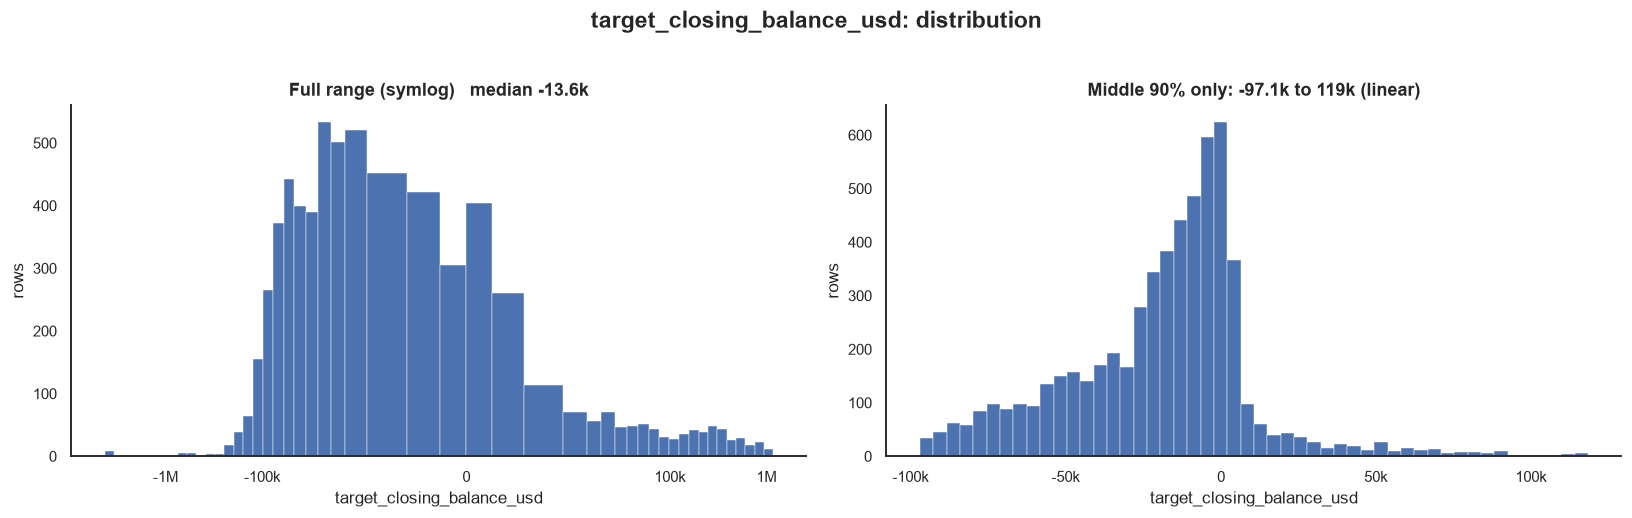

Skew check: the mean sits far outside the middle half, so any model scored on plain RMSE will be graded almost entirely on the few largest accounts.


,value,readable
min,-4.299164e+06,-4.3M
p1,-1.668868e+05,-167k
p5,-9.710492e+04,-97.1k
p25,-3.971932e+04,-39.7k
p50,-1.359692e+04,-13.6k
p75,-5.715125e+02,-571.5
p95,1.194895e+05,119k
p99,5.494539e+05,549k
max,1.153779e+06,1.2M
mean,-1.147308e+04,-11.5k


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))

scale, median = hist_panel(axes[0], df[TARGET_COLUMN], bins=50)
axes[0].set_title(f"Full range ({scale})   median {compact(median)}")
axes[0].set_xlabel(TARGET_COLUMN)
axes[0].set_ylabel("rows")

core = df[TARGET_COLUMN].dropna()
low, high = core.quantile([0.05, 0.95])
middle = core[core.between(low, high)]
hist_panel(axes[1], middle, bins=50, force_symlog=False)
axes[1].set_title(f"Middle 90% only: {compact(low)} to {compact(high)} (linear)")
axes[1].set_xlabel(TARGET_COLUMN)
axes[1].set_ylabel("rows")

fig.suptitle(f"{TARGET_COLUMN}: distribution", y=1.02)
fig.tight_layout()
plt.show()

quantiles = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
summary = pd.DataFrame({
    "value": [core.min(), *core.quantile(quantiles), core.max(), core.mean()],
}, index=["min", *[f"p{int(q * 100)}" for q in quantiles], "max", "mean"])
summary["readable"] = summary["value"].map(compact)
print("Skew check: the mean sits far outside the middle half, so any model "
      "scored on plain RMSE will be graded almost entirely on the few "
      "largest accounts.")
display(summary)

### 2. Target over time

Two panels rather than two lines on one axis: the mean is so much larger than
the median that sharing an axis flattens the median into the zero line and
hides everything it has to say.

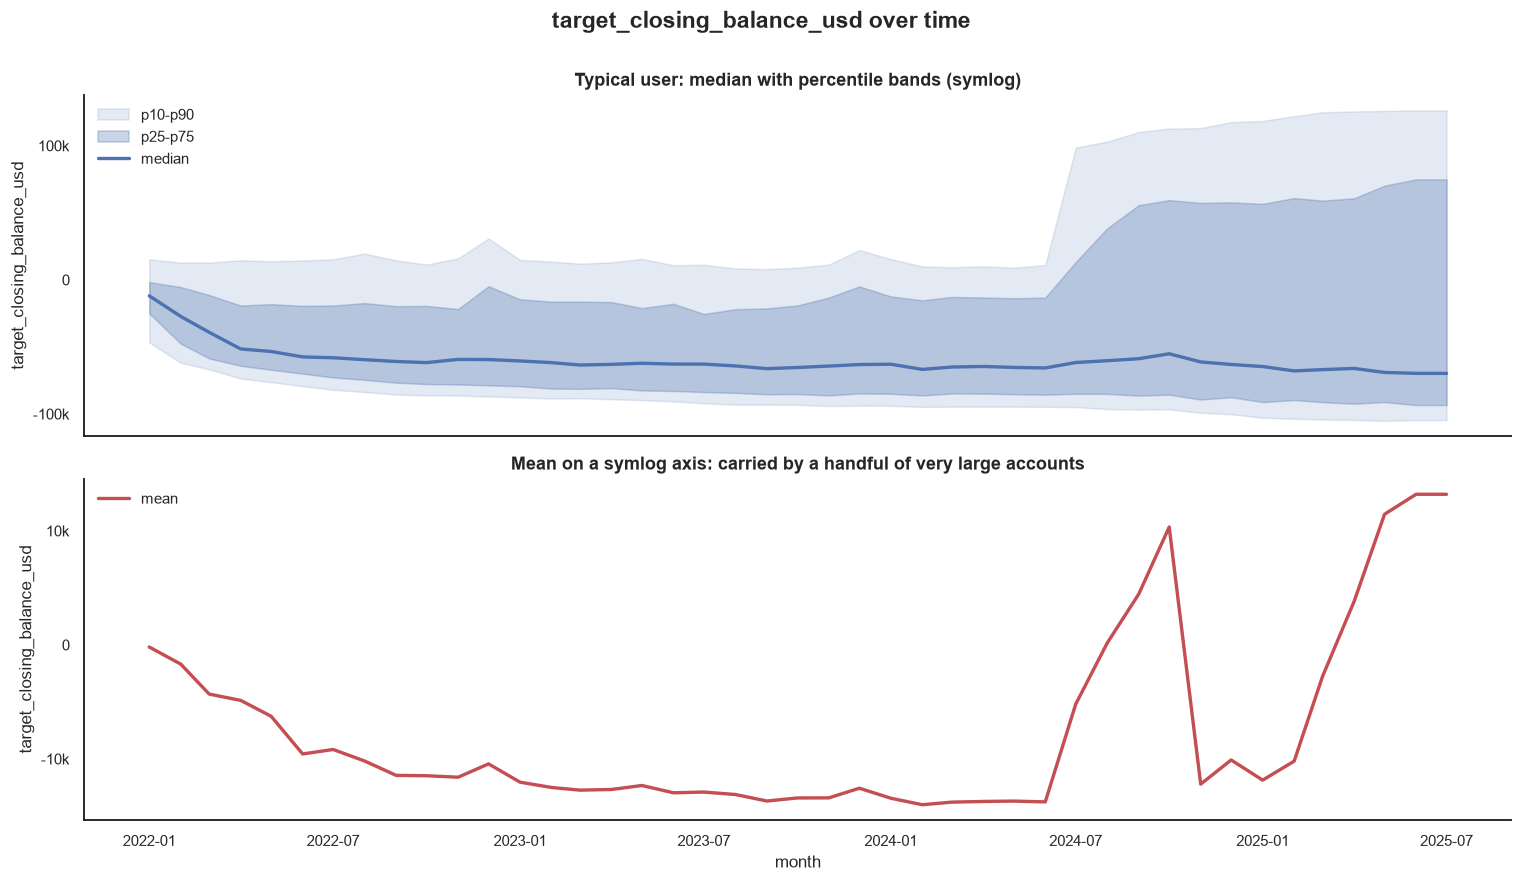

Largest month-on-month move in the mean: 2024-11-01 (10.9k -> -17.6k), while the median went to -15.2k.
Months covered: 43 (2022-01-01 to 2025-07-01); rows per month 150-150.


In [7]:
if TIME_COLUMN is None:
    print("Target over time skipped: set TIME_COLUMN to the date/month column.")
else:
    over_time = (
        pd.DataFrame({"time": time_values, "target": df[TARGET_COLUMN]})
        .dropna(subset=["time"])
        .groupby("time")["target"]
        .agg(
            mean="mean",
            median="median",
            p10=lambda s: s.quantile(0.10),
            p25=lambda s: s.quantile(0.25),
            p75=lambda s: s.quantile(0.75),
            p90=lambda s: s.quantile(0.90),
            rows="count",
        )
        .reset_index()
    )

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

    axes[0].fill_between(over_time["time"], over_time["p10"], over_time["p90"],
                         color=BLUE, alpha=0.15, label="p10-p90")
    axes[0].fill_between(over_time["time"], over_time["p25"], over_time["p75"],
                         color=BLUE, alpha=0.30, label="p25-p75")
    axes[0].plot(over_time["time"], over_time["median"], color=BLUE, lw=2.2, label="median")
    # Symlog here too: after mid-2024 the p10-p90 band opens out past 1M, and
    # on a linear axis that band alone flattens the median back onto zero --
    # the same failure this panel exists to avoid.
    band_linthresh = linthresh_for(
        pd.concat([over_time["median"], over_time["p25"], over_time["p75"]])
    )
    axes[0].set_yscale("symlog", linthresh=band_linthresh)
    tidy_symlog_ticks(axes[0], band_linthresh, "y", max_ticks=9)
    axes[0].set_title("Typical user: median with percentile bands (symlog)")
    axes[0].set_ylabel(TARGET_COLUMN)
    axes[0].legend(loc="upper left")
    money_axis(axes[0], "y")

    axes[1].plot(over_time["time"], over_time["mean"], color=RED, lw=2.2, label="mean")
    mean_linthresh = linthresh_for(over_time["mean"])
    axes[1].set_yscale("symlog", linthresh=mean_linthresh)
    tidy_symlog_ticks(axes[1], mean_linthresh, "y", max_ticks=9)
    axes[1].set_title("Mean on a symlog axis: carried by a handful of very large accounts")
    axes[1].set_ylabel(TARGET_COLUMN)
    axes[1].set_xlabel(TIME_COLUMN)
    axes[1].legend(loc="upper left")
    money_axis(axes[1], "y")

    sns.despine(fig=fig)
    fig.suptitle(f"{TARGET_COLUMN} over time", y=1.0)
    fig.tight_layout()
    plt.show()

    # A jump in the mean with a flat median means new extreme rows arrived,
    # not that every user moved. Worth knowing before splitting on time.
    step = over_time["mean"].diff().abs()
    if len(step.dropna()):
        break_at = over_time.loc[step.idxmax()]
        print(f"Largest month-on-month move in the mean: {break_at['time'].date()} "
              f"({compact(over_time['mean'].iloc[step.idxmax() - 1])} -> "
              f"{compact(break_at['mean'])}), while the median went to "
              f"{compact(break_at['median'])}.")
    print(f"Months covered: {len(over_time)} "
          f"({over_time['time'].min().date()} to {over_time['time'].max().date()}); "
          f"rows per month {over_time['rows'].min()}-{over_time['rows'].max()}.")

### 3. Missing values

As bars rather than a table: the columns come in blocks that share a cause,
and the blocks are obvious by bar length long before the numbers are.

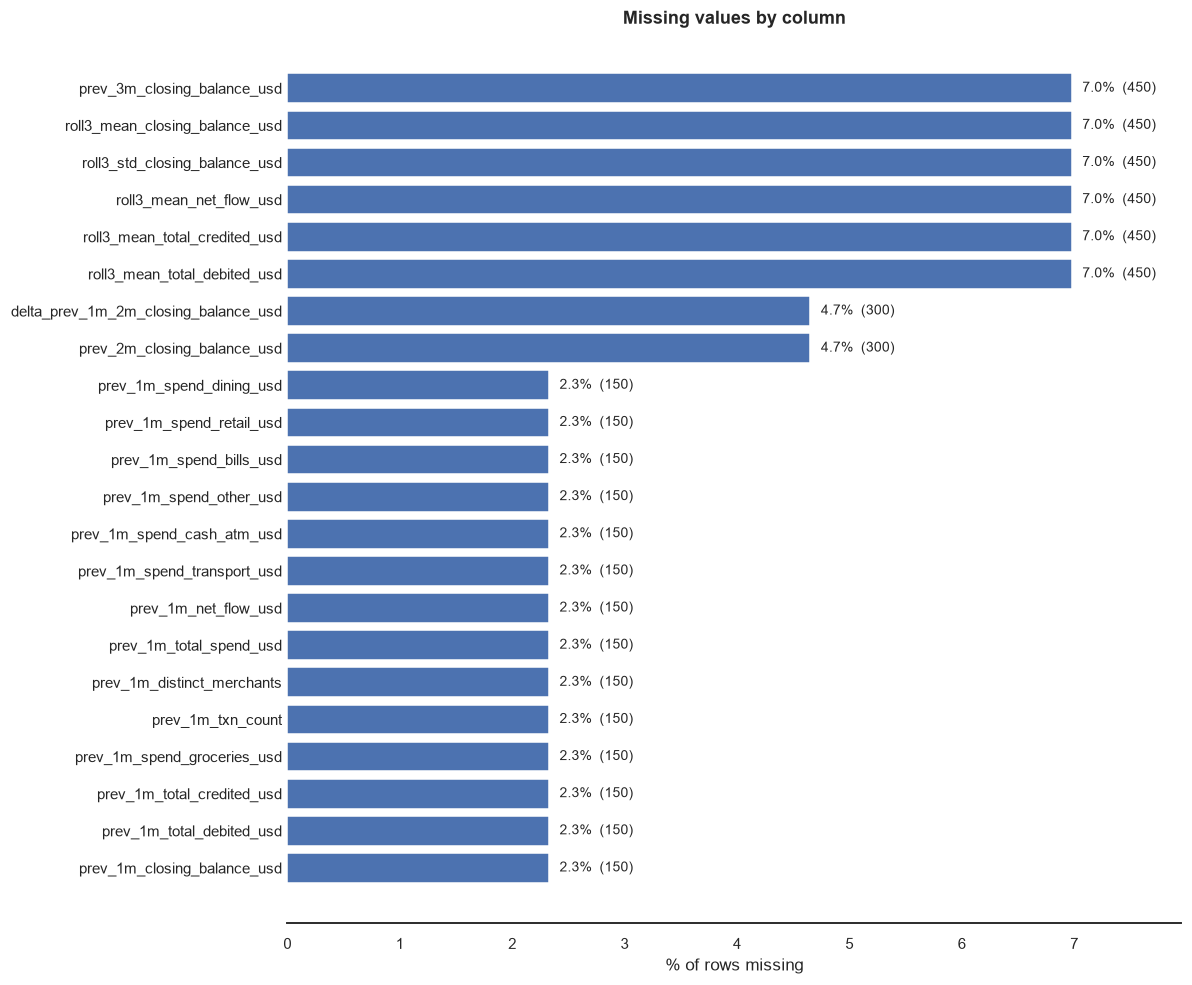

22 of 28 columns have gaps; worst is roll3_mean_total_debited_usd at 7.0%.
100% of all missing cells fall in each user's first three months, which is what a lag/rolling window looks like.


In [8]:
missing_pct = (100 * df.isna().mean()).pipe(lambda s: s[s > 0]).sort_values()

if missing_pct.empty:
    print("No missing values.")
else:
    fig, ax = plt.subplots(figsize=(11, max(3.0, 0.36 * len(missing_pct) + 1.2)))
    counts = df.isna().sum()[missing_pct.index]
    bars = ax.barh(missing_pct.index, missing_pct.to_numpy(), color=BLUE)
    label_bars(ax, bars,
               [f"{pct:.1f}%  ({counts[name]:,})" for name, pct in missing_pct.items()])
    ax.set_xlabel("% of rows missing")
    ax.set_title("Missing values by column")
    sns.despine(ax=ax, left=True)
    ax.tick_params(axis="y", length=0)
    fig.tight_layout()
    plt.show()

    print(f"{len(missing_pct)} of {len(df.columns)} columns have gaps; "
          f"worst is {missing_pct.idxmax()} at {missing_pct.max():.1f}%.")
    if USER_COLUMN and TIME_COLUMN:
        # Lag and rolling features are empty for a user's first months by
        # construction. If that is all this is, the gaps sit at the start of
        # each user's history and nowhere else.
        first_months = (
            df.assign(_rank=df.groupby(USER_COLUMN)[TIME_COLUMN].rank(method="first"))
            .loc[lambda t: t["_rank"] <= 3]
        )
        share = 100 * first_months[missing_pct.index].isna().sum().sum() / max(
            df[missing_pct.index].isna().sum().sum(), 1)
        print(f"{share:.0f}% of all missing cells fall in each user's first three "
              f"months, which is what a lag/rolling window looks like.")

### 4. Feature distributions

One panel per numeric feature, each on the scale that suits it -- `df.hist()`
forced a linear axis on all of them, which left most panels as a single bar.
The title says which scale a panel is using.

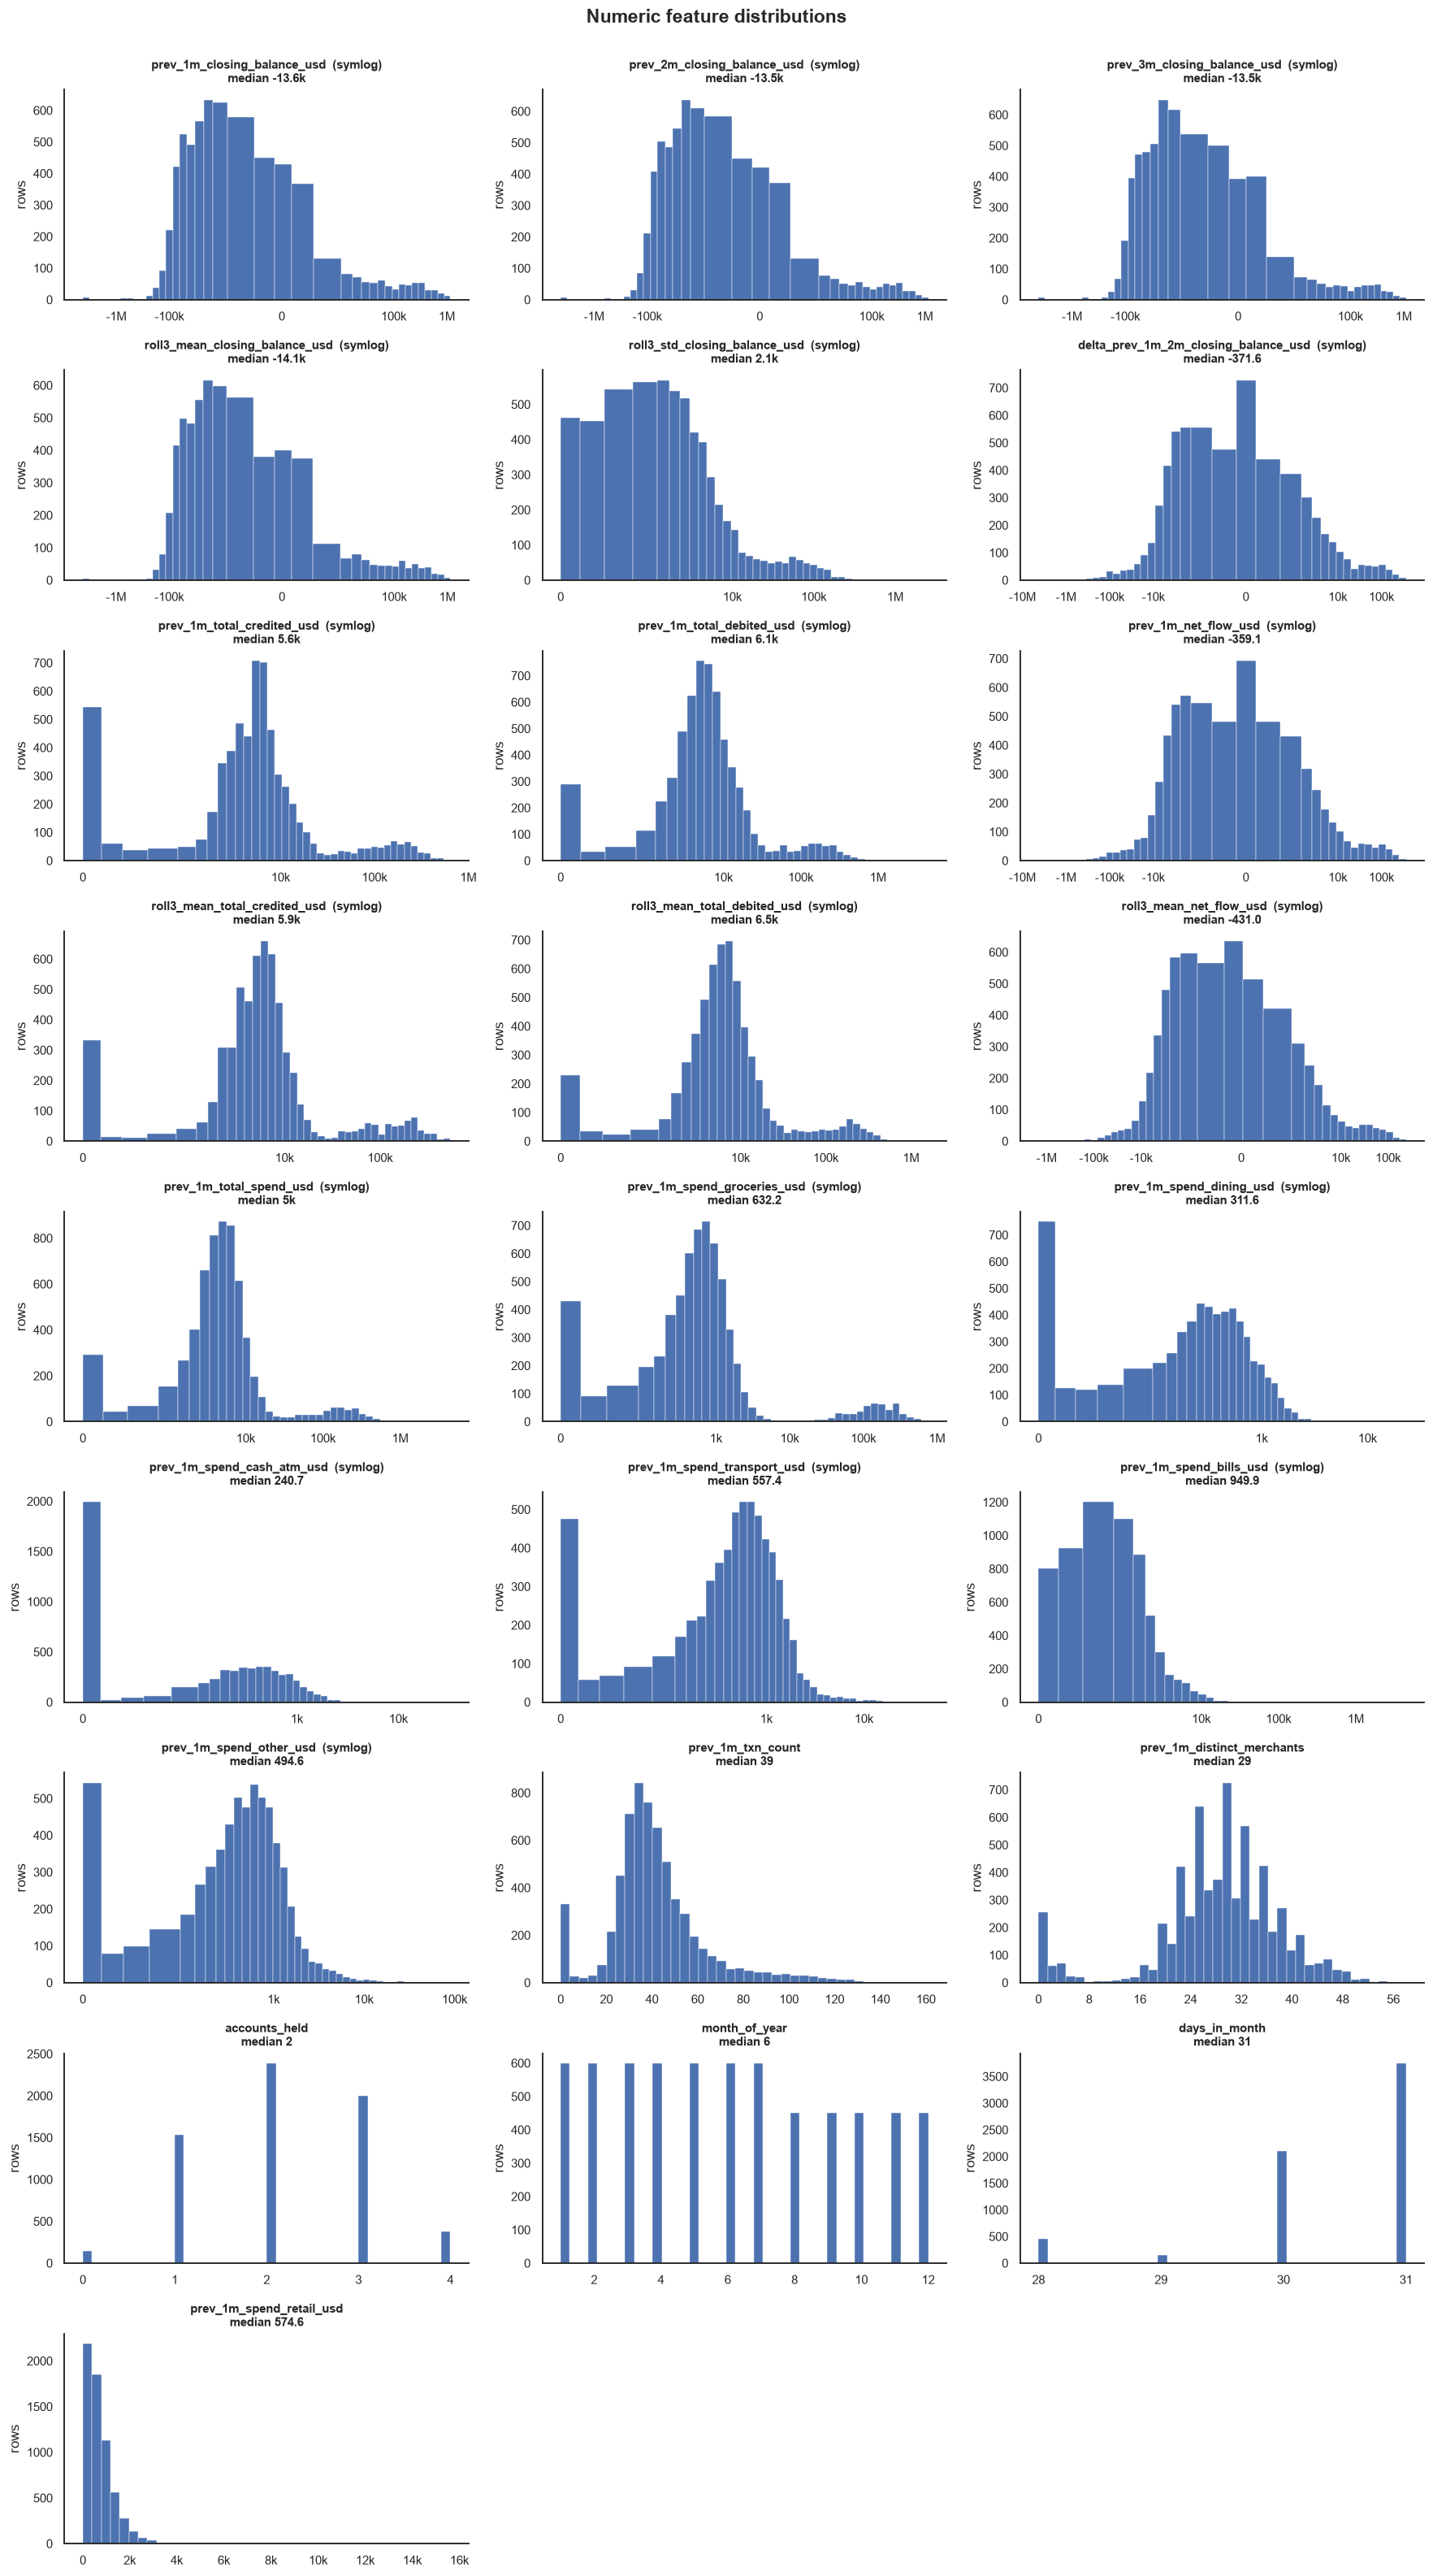

19 of 25 features are heavy-tailed enough to need a symlog axis. Scale or rank-transform those before fitting anything distance-based.


In [9]:
if not feature_columns:
    print("Feature distributions skipped: no numeric feature columns found.")
else:
    # Heavy-tailed columns first: they are the ones worth looking at closely,
    # and grouping them keeps the eye from switching scale every panel.
    ordered = sorted(feature_columns, key=lambda column: not heavy_tailed(df[column]))
    n_columns = 3
    n_rows = int(np.ceil(len(ordered) / n_columns))
    fig, axes = plt.subplots(n_rows, n_columns,
                             figsize=(5.4 * n_columns, 3.2 * n_rows), squeeze=False)
    flat = axes.ravel()
    for ax, column in zip(flat, ordered):
        scale, median = hist_panel(ax, df[column], bins=40)
        suffix = "  (symlog)" if scale == "symlog" else ""
        ax.set_title(f"{column}{suffix}\nmedian {compact(median)}", fontsize=10)
        ax.set_ylabel("rows")
    for ax in flat[len(ordered):]:
        ax.set_visible(False)
    fig.suptitle("Numeric feature distributions", y=1.0)
    fig.tight_layout()
    plt.show()

    print(f"{sum(heavy_tailed(df[c]) for c in feature_columns)} of "
          f"{len(feature_columns)} features are heavy-tailed enough to need a "
          f"symlog axis. Scale or rank-transform those before fitting anything "
          f"distance-based.")

### 5. Near-constant features

A feature whose most common value covers almost every row carries almost no
signal. Bars show how close each feature is to that, so the borderline ones
are visible instead of only the ones past a fixed cut.

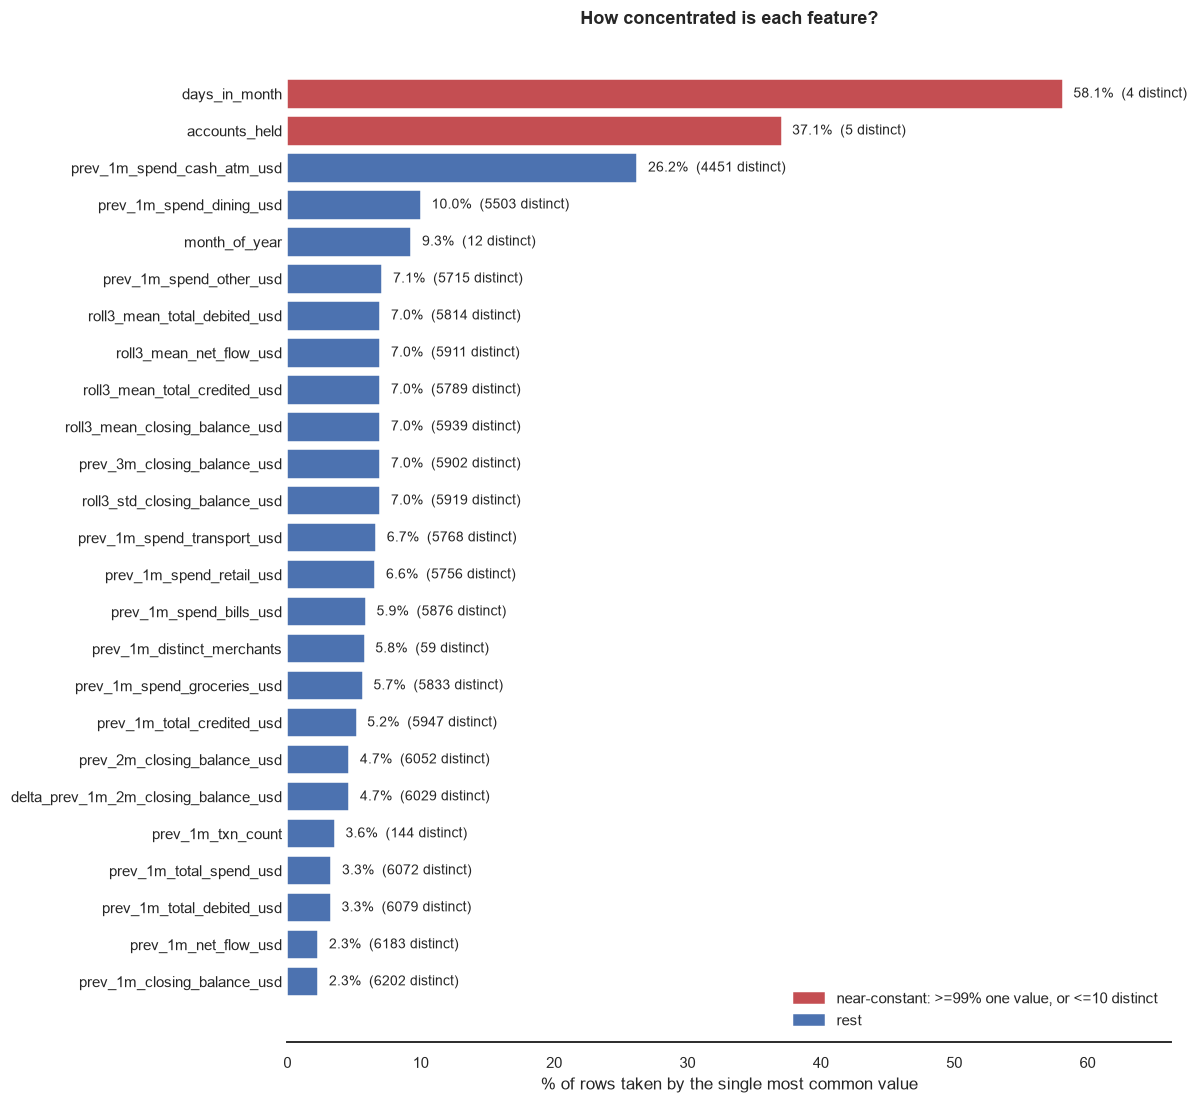

Near-constant features:


,n_unique,most_common_value,most_common_pct
feature,,,
days_in_month,4,31.0,58.139535
accounts_held,5,2.0,37.054264


In [10]:
dominance = []
for column in feature_columns:
    shares = df[column].value_counts(dropna=False, normalize=True)
    dominance.append({
        "feature": column,
        "n_unique": int(df[column].nunique(dropna=False)),
        "most_common_value": shares.index[0] if not shares.empty else np.nan,
        "most_common_pct": 100 * shares.iloc[0] if not shares.empty else np.nan,
    })
dominance = pd.DataFrame(dominance).set_index("feature").sort_values("most_common_pct")

# Flagged: one value covers 99% of rows, or there are 10 or fewer distinct
# values in the whole column.
flagged = (dominance["most_common_pct"] >= 99) | (dominance["n_unique"] <= 10)

fig, ax = plt.subplots(figsize=(11, max(3.0, 0.36 * len(dominance) + 1.2)))
bars = ax.barh(dominance.index, dominance["most_common_pct"].to_numpy(),
               color=[RED if f else BLUE for f in flagged])
label_bars(ax, bars, [
    f"{pct:.1f}%  ({int(n)} distinct)"
    for pct, n in zip(dominance["most_common_pct"], dominance["n_unique"])
])
ax.set_xlabel("% of rows taken by the single most common value")
ax.set_title("How concentrated is each feature?")
ax.legend(handles=[
    plt.Rectangle((0, 0), 1, 1, color=RED),
    plt.Rectangle((0, 0), 1, 1, color=BLUE),
], labels=["near-constant: >=99% one value, or <=10 distinct", "rest"],
    loc="lower right")
sns.despine(ax=ax, left=True)
ax.tick_params(axis="y", length=0)
fig.tight_layout()
plt.show()

print("Near-constant features:")
display(dominance[flagged].sort_values("most_common_pct", ascending=False)
        if flagged.any() else pd.DataFrame({"message": ["None found"]}))

### Selecting on the training months only

Everything below reads correlations against the target, and that is a selection
decision. Computed over all 42 months it would let the held-out months help
choose the columns -- the same leak as fitting a scaler before the split, and no
later score can undo it.

So the slice is taken here, once, and checks 6 and 7 both use it. The number of
held-out months is read from `config/ml_config.yaml` rather than typed again, so
this cannot drift away from what `python -m src.train` actually does.


In [ ]:
from src.config.config import load_config

_config = load_config()
TEST_MONTHS = int(_config["split"]["test_months"])

if TIME_COLUMN is None:
    print("No time column detected; selecting on every row. Set TIME_COLUMN "
          "above to restrict this to the training months.")
    train_df = df
else:
    _months = pd.to_datetime(df[TIME_COLUMN], errors="coerce").dt.to_period("M")
    _ordered = _months.dropna().sort_values().unique()
    _train_months = _ordered[:-TEST_MONTHS] if TEST_MONTHS else _ordered
    train_df = df[_months.isin(_train_months)]
    print(f"Selecting on {len(_train_months)} of {len(_ordered)} months "
          f"({_train_months[0]} to {_train_months[-1]}), holding out the "
          f"last {TEST_MONTHS}.")
    print(f"{len(train_df):,} of {len(df):,} rows.")


### 6. Correlations

Three views. The paired bar chart ranks each feature against the target under
both Pearson and Spearman, because on this target the two disagree and the
disagreement is the point: Pearson reads straight-line strength, and a handful of
very large balances can set it; Spearman reads rank, and they cannot. Where they
differ, Spearman is the one to trust here. The matrix keeps only its lower
triangle -- the square version drew every pair twice and gave its darkest cells
to the diagonal, which says nothing.


In [ ]:
if len(numeric_columns) < 2:
    print("Correlation checks skipped: fewer than two numeric columns found.")
else:
    # Both measures, on the training months only.
    pearson = train_df[numeric_columns].corr()
    spearman = train_df[numeric_columns].corr(method="spearman")

    target_r = pearson[TARGET_COLUMN].drop(TARGET_COLUMN)
    target_rho = spearman[TARGET_COLUMN].drop(TARGET_COLUMN)

    # Ordered by the stronger of the two, so a feature only one measure rates
    # highly still surfaces near the top instead of being buried.
    strength = pd.concat([target_r.abs(), target_rho.abs()], axis=1).max(axis=1)
    order = strength.sort_values().index

    positions = np.arange(len(order))
    height = 0.4

    fig, ax = plt.subplots(figsize=(11, max(3.6, 0.52 * len(order) + 1.2)))
    bars_r = ax.barh(positions + height / 2, target_r[order].abs().to_numpy(),
                     height=height, color=BLUE, label="|Pearson r|")
    bars_rho = ax.barh(positions - height / 2, target_rho[order].abs().to_numpy(),
                       height=height, color=RED, label="|Spearman rho|")
    # Sign restored in the label: the bar ranks strength, the text says
    # direction, so a strong negative predictor is not read as a weak one.
    label_bars(ax, bars_r, [f"{target_r[name]:+.3f}" for name in order])
    label_bars(ax, bars_rho, [f"{target_rho[name]:+.3f}" for name in order])
    ax.set_yticks(positions, list(order), fontsize=9)
    ax.set_xlim(0, 1.0)
    ax.set_xlabel(f"correlation with {TARGET_COLUMN}   (sign shown on the bar)")
    ax.set_title(f"Feature correlation with {TARGET_COLUMN}, training months only")
    ax.legend(loc="lower right")
    sns.despine(ax=ax, left=True)
    ax.tick_params(axis="y", length=0)
    fig.tight_layout()
    plt.show()

    # Where the two measures disagree most. A large gap means the Pearson figure
    # is being set by the tail rather than by the bulk of the users.
    gap = (target_rho.abs() - target_r.abs()).sort_values()
    widest = pd.concat([gap.head(3), gap.tail(3)])
    print("Largest Pearson/Spearman disagreements "
          "(positive = Spearman sees more than Pearson):")
    display(
        pd.DataFrame({
            "pearson_r": target_r[widest.index],
            "spearman_rho": target_rho[widest.index],
            "rho_minus_r": widest,
        }).round(3)
    )

    # Masking the upper triangle leaves the first row and the last column with
    # nothing in them; dropping the pair removes a band of empty cells and the
    # labels that go with it.
    lower = spearman.iloc[1:, :-1]
    size = len(lower)
    mask = np.triu(np.ones(lower.shape, dtype=bool), k=1)
    side = max(8.0, 0.58 * size)
    fig, ax = plt.subplots(figsize=(side, side * 0.88))
    sns.heatmap(
        lower, mask=mask, cmap="vlag", vmin=-1, vmax=1, center=0,
        square=True, linewidths=0.5, linecolor="white",
        annot=size <= 30, fmt=".2f", annot_kws={"size": 7},
        cbar_kws={"shrink": 0.45, "label": "Spearman rho"}, ax=ax,
    )
    ax.set_title("Numeric correlation matrix, Spearman (lower triangle)", pad=14)
    ax.tick_params(axis="x", rotation=90, labelsize=9, length=0)
    ax.tick_params(axis="y", rotation=0, labelsize=9, length=0)
    fig.tight_layout()
    plt.show()

    print("Both measures are univariate: each column is scored against the "
          "target on its own, so a column that only matters alongside another "
          "ranks low here, and a redundant pair both rank high. Check 7 handles "
          "the redundancy half. The combination half is what the gain "
          "importance printed by `python -m src.train` answers.")


### 7. Highly correlated feature pairs

Pairs above 0.90, by rank correlation and on the training months, to match check
6. Keeping both members of a pair makes a linear model's coefficients unstable
and splits the importance of one signal across two columns, so this is the list
to prune from before selection is settled.


In [ ]:
if len(feature_columns) < 2:
    print("Pair check skipped: fewer than two numeric features found.")
else:
    # Spearman, to match check 6: a pair that is a rank duplicate is redundant
    # whether or not the relationship between them is linear.
    pair_correlation = train_df[feature_columns].corr(method="spearman").abs()
    pairs = (
        pair_correlation
        .where(np.triu(np.ones(pair_correlation.shape), k=1).astype(bool))
        .stack()
        .sort_values()
        .rename("absolute_correlation")
    )
    strong = pairs[pairs >= 0.90]

    if strong.empty:
        print("No feature pairs at or above 0.90.")
    else:
        labels = [f"{a}\nx {b}" for a, b in strong.index]
        fig, ax = plt.subplots(figsize=(11, max(3.2, 0.62 * len(strong) + 1.2)))
        bars = ax.barh(range(len(strong)), strong.to_numpy(), color=RED)
        label_bars(ax, bars, [f"{value:.3f}" for value in strong])
        ax.set_yticks(range(len(strong)), labels, fontsize=9)
        ax.set_xlim(0.85, 1.0)
        ax.set_xlabel("|Spearman rho|")
        ax.set_title("Feature pairs correlated at 0.90 or above, training months")
        sns.despine(ax=ax, left=True)
        ax.tick_params(axis="y", length=0)
        fig.tight_layout()
        plt.show()

        # Columns showing up in more than one pair are the ones to drop first,
        # since one decision clears several pairs at once.
        appearances = pd.Series(
            [name for pair in strong.index for name in pair]).value_counts()
        repeated = appearances[appearances > 1]
        if not repeated.empty:
            print("Columns appearing in more than one pair (drop these first):")
            display(repeated.rename("pairs").to_frame())

    print("\nWhatever you settle on goes in data.drop_columns in "
          "config/ml_config.yaml, one entry per column, with the measurement "
          "that justifies it in a comment beside it.")


### 8. User differences

Whether the target is a property of the user or of the month. If per-user
levels are spread this widely, a model without a user-level feature is mostly
guessing which user a row belongs to.

Users: 150; rows per user 43-43


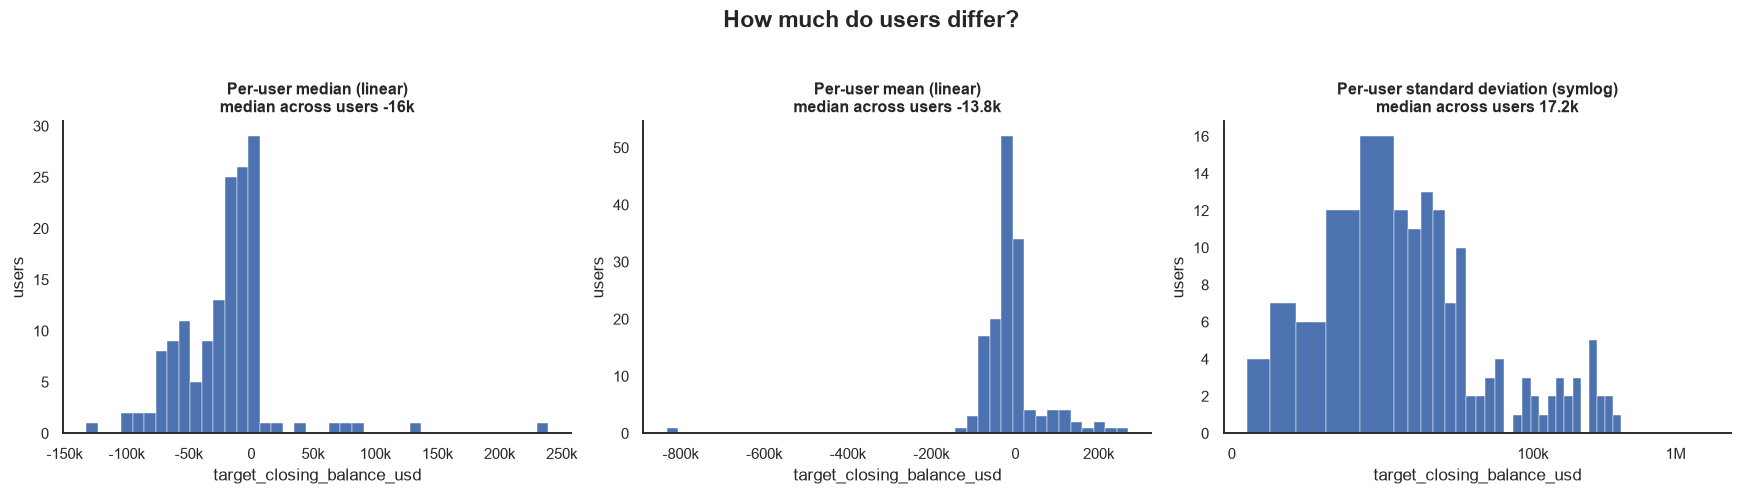

Spread between user means: 92.3k
Average spread within a user: 61.2k
Ratio: 1.51  (user identity dominates)


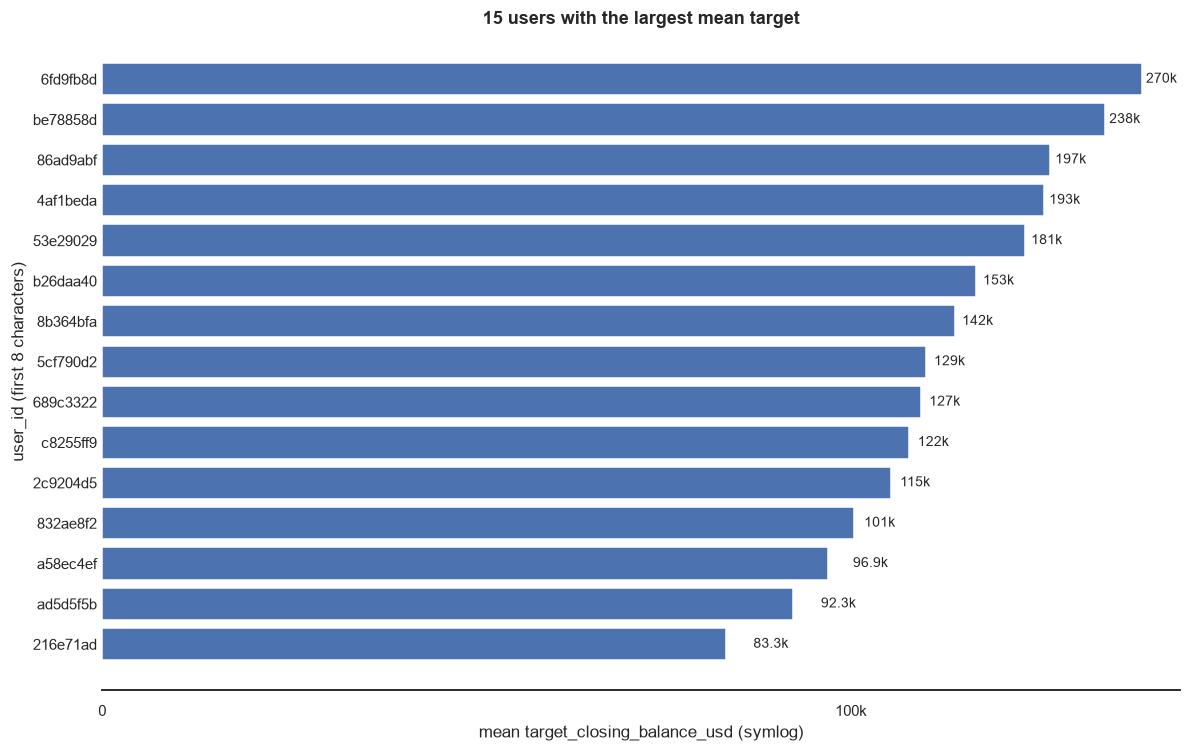

In [13]:
if USER_COLUMN is None:
    print("User checks skipped: set USER_COLUMN to the user identifier column.")
else:
    user_summary = (
        df.groupby(USER_COLUMN, dropna=False)
        .agg(
            rows=(TARGET_COLUMN, "size"),
            target_mean=(TARGET_COLUMN, "mean"),
            target_median=(TARGET_COLUMN, "median"),
            target_std=(TARGET_COLUMN, "std"),
        )
        .sort_values("target_mean", ascending=False)
    )
    print(f"Users: {len(user_summary):,}; rows per user "
          f"{user_summary['rows'].min()}-{user_summary['rows'].max()}")

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
    for ax, column, title in zip(
        axes,
        ["target_median", "target_mean", "target_std"],
        ["Per-user median", "Per-user mean", "Per-user standard deviation"],
    ):
        scale, median = hist_panel(ax, user_summary[column], bins=40)
        ax.set_title(f"{title} ({scale})\nmedian across users {compact(median)}", fontsize=10.5)
        ax.set_xlabel(TARGET_COLUMN)
        ax.set_ylabel("users")
    fig.suptitle("How much do users differ?", y=1.02)
    fig.tight_layout()
    plt.show()

    # Between-user vs within-user spread. A ratio well above 1 means most of
    # the variance is the user, not the month.
    between = user_summary["target_mean"].std()
    within = user_summary["target_std"].mean()
    print(f"Spread between user means: {compact(between)}")
    print(f"Average spread within a user: {compact(within)}")
    print(f"Ratio: {between / within:.2f}  "
          f"({'user identity dominates' if between > within else 'month-to-month movement dominates'})")

    top = user_summary["target_mean"].head(15).iloc[::-1]
    fig, ax = plt.subplots(figsize=(11, 0.36 * len(top) + 1.6))
    bars = ax.barh([str(name)[:8] for name in top.index], top.to_numpy(), color=BLUE)
    label_bars(ax, bars, [compact(value) for value in top])
    top_linthresh = linthresh_for(top)
    ax.set_xscale("symlog", linthresh=top_linthresh)
    tidy_symlog_ticks(ax, top_linthresh, "x", max_ticks=9)
    money_axis(ax, "x")
    ax.set_xlabel(f"mean {TARGET_COLUMN} (symlog)")
    ax.set_ylabel(f"{USER_COLUMN} (first 8 characters)")
    ax.set_title("15 users with the largest mean target")
    sns.despine(ax=ax, left=True)
    ax.tick_params(axis="y", length=0)
    fig.tight_layout()
    plt.show()

### 9. Outliers

Share of rows outside 1.5 x IQR, per column. On skewed data this rule flags
ordinary large values as well as genuine errors, so read it as "how skewed is
this column" rather than "how many mistakes are in it".

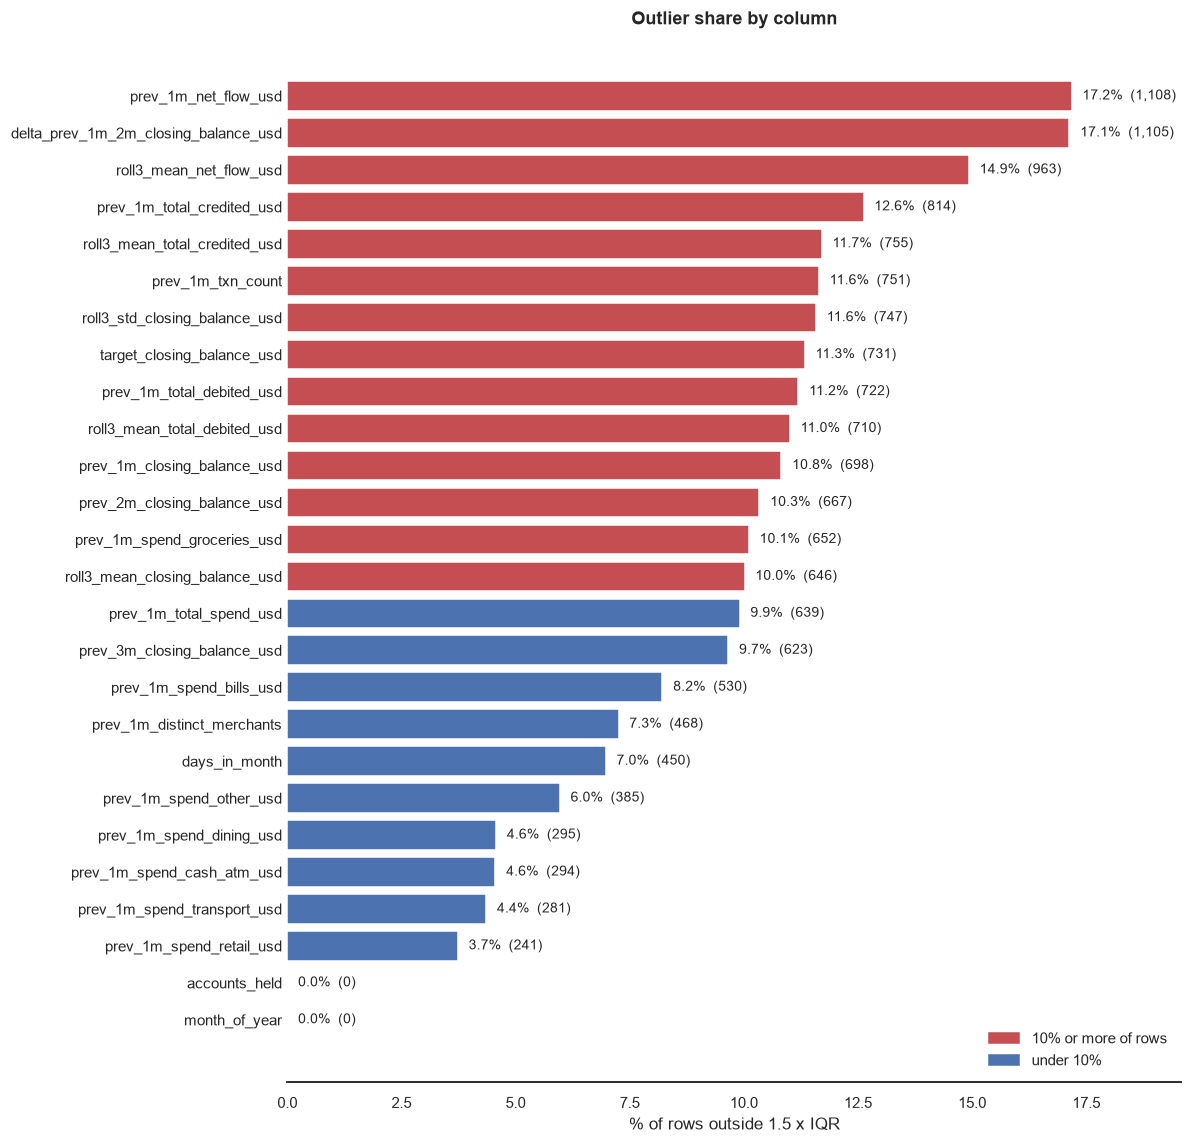

,lower_bound,upper_bound,outlier_count,outlier_pct
feature,,,,
prev_1m_net_flow_usd,-8.6k,6.8k,1108,17.178295
delta_prev_1m_2m_closing_balance_usd,-8.4k,6.6k,1105,17.131783
roll3_mean_net_flow_usd,-6.5k,5k,963,14.930233
prev_1m_total_credited_usd,-6.6k,19.3k,814,12.620155
roll3_mean_total_credited_usd,-5.4k,18.3k,755,11.705426
prev_1m_txn_count,3.6,76.6,751,11.643411
roll3_std_closing_balance_usd,-5.4k,11.2k,747,11.581395
target_closing_balance_usd,-98.4k,58.2k,731,11.333333
prev_1m_total_debited_usd,-8.3k,23k,722,11.193798


In [14]:
outlier_rows = []
for column in numeric_columns:
    values = df[column].dropna()
    if values.empty:
        continue
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower_bound, upper_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (df[column] < lower_bound) | (df[column] > upper_bound)
    outlier_rows.append({
        "feature": column,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": int(mask.sum()),
        "outlier_pct": 100 * float(mask.mean()),
    })
outliers = pd.DataFrame(outlier_rows).set_index("feature").sort_values("outlier_pct")

if outliers.empty:
    print("No numeric columns to check.")
else:
    fig, ax = plt.subplots(figsize=(11, max(3.0, 0.36 * len(outliers) + 1.2)))
    bars = ax.barh(outliers.index, outliers["outlier_pct"].to_numpy(),
                   color=[RED if v >= 10 else BLUE for v in outliers["outlier_pct"]])
    label_bars(ax, bars, [f"{pct:.1f}%  ({count:,})" for pct, count
                          in zip(outliers["outlier_pct"], outliers["outlier_count"])])
    ax.set_xlabel("% of rows outside 1.5 x IQR")
    ax.set_title("Outlier share by column")
    ax.legend(handles=[
        plt.Rectangle((0, 0), 1, 1, color=RED),
        plt.Rectangle((0, 0), 1, 1, color=BLUE),
    ], labels=["10% or more of rows", "under 10%"], loc="lower right")
    sns.despine(ax=ax, left=True)
    ax.tick_params(axis="y", length=0)
    fig.tight_layout()
    plt.show()

    display(outliers.sort_values("outlier_pct", ascending=False)
            .assign(lower_bound=lambda t: t["lower_bound"].map(compact),
                    upper_bound=lambda t: t["upper_bound"].map(compact))
            .head(15))

### 10. Months per user

How much history each user actually has. Uneven history means lag and rolling
features are missing for different users at different times, and it decides
whether a time-based split is even possible.

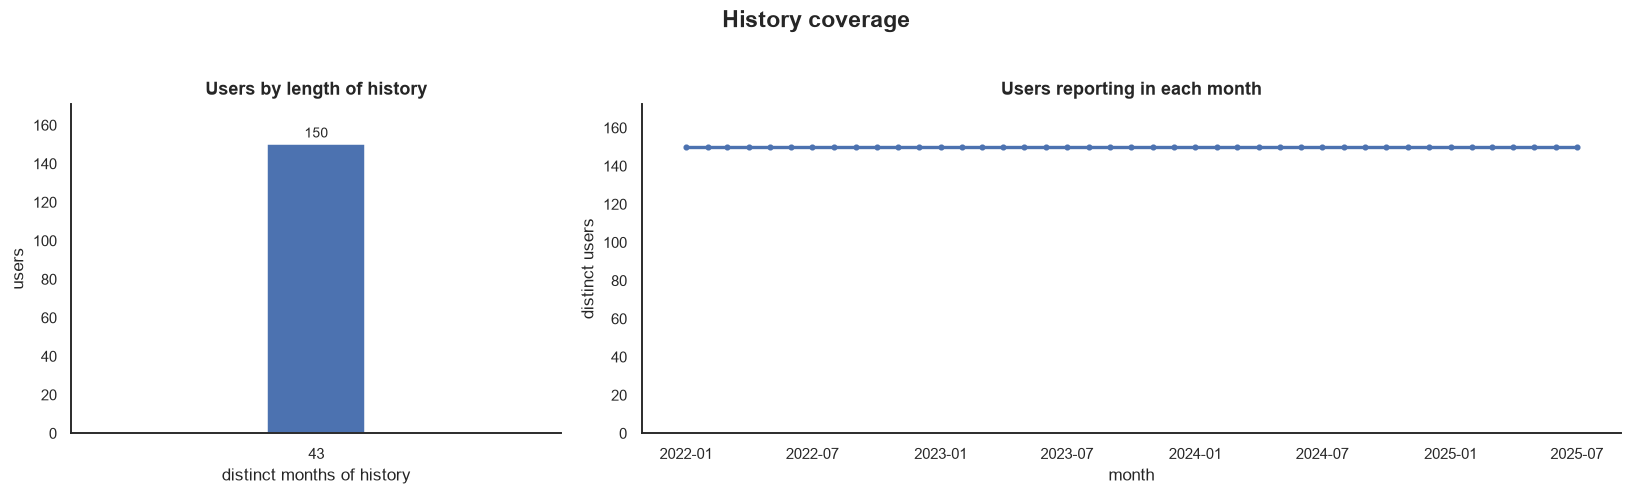

Every one of the 150 users has exactly 43 months. The panel is balanced, so a split by date gives every user the same amount of history on both sides.


In [15]:
if USER_COLUMN is None or TIME_COLUMN is None:
    print("Months per user skipped: set both USER_COLUMN and TIME_COLUMN.")
else:
    months_per_user = (
        df.assign(_month=time_values.dt.to_period("M"))
        .dropna(subset=["_month"])
        .groupby(USER_COLUMN, dropna=False)["_month"]
        .nunique()
    )
    spread = months_per_user.value_counts().sort_index()

    fig, axes = plt.subplots(1, 2, figsize=(15, 4.4),
                             gridspec_kw={"width_ratios": [1, 2]})

    bars = axes[0].bar([str(m) for m in spread.index], spread.to_numpy(),
                       color=BLUE, width=min(0.6, 0.18 * len(spread) + 0.12))
    axes[0].set_xlim(-0.75, len(spread) - 0.25)
    label_bars(axes[0], bars, [f"{count:,}" for count in spread], orientation="v")
    axes[0].set_xlabel("distinct months of history")
    axes[0].set_ylabel("users")
    axes[0].set_title("Users by length of history")
    sns.despine(ax=axes[0])

    # Users present per month: the same question asked the other way round,
    # and the one that shows whether the panel is ragged at either end.
    per_month = (
        df.assign(_month=time_values.dt.to_period("M"))
        .dropna(subset=["_month"])
        .groupby("_month")[USER_COLUMN]
        .nunique()
    )
    axes[1].plot(per_month.index.to_timestamp(), per_month.to_numpy(),
                 color=BLUE, lw=2.2, marker="o", markersize=3)
    axes[1].set_ylim(0, per_month.max() * 1.15)
    axes[1].set_xlabel(TIME_COLUMN)
    axes[1].set_ylabel("distinct users")
    axes[1].set_title("Users reporting in each month")
    sns.despine(ax=axes[1])

    fig.suptitle("History coverage", y=1.02)
    fig.tight_layout()
    plt.show()

    if len(spread) == 1:
        length = int(spread.index[0])
        print(f"Every one of the {len(months_per_user):,} users has exactly "
              f"{length} months. The panel is balanced, so a split by date "
              f"gives every user the same amount of history on both sides.")
    else:
        print(f"History length ranges from {months_per_user.min()} to "
              f"{months_per_user.max()} months "
              f"(median {months_per_user.median():.0f}).")
        short = months_per_user[months_per_user < 4]
        if not short.empty:
            print(f"{len(short):,} users have fewer than 4 months, so their "
                  f"rolling features are mostly empty.")